In [284]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

%matplotlib inline

In [285]:
df = pd.read_csv('vacancies.csv')

In [286]:
df.head()

,vacancy_id,salary_from,salary_to,experience,city,employment_type
0,37351176,60000.0,70000.0,Нет опыта,Екатеринбург,Удалённая работа
1,53503796,140000.0,210000.0,От 1 года до 3 лет,Москва,Полная занятость
2,20319022,NaN,NaN,Более 6 лет,Москва,Полная занятость
3,40619665,145000.0,215000.0,От 1 года до 3 лет,Нижний Новгород,Полная занятость
4,14675717,NaN,NaN,Более 6 лет,Москва,Полная занятость


In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   vacancy_id       100000 non-null  int64  
 1   salary_from      68385 non-null   float64
 2   salary_to        69219 non-null   float64
 3   experience       100000 non-null  object 
 4   city             100000 non-null  object 
 5   employment_type  100000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 4.6+ MB


In [288]:
df.describe()

,vacancy_id,salary_from,salary_to
count,1.000000e+05,6.838500e+04,6.921900e+04
mean,5.502163e+07,4.547105e+05,6.155720e+05
std,2.595831e+07,2.466358e+06,3.377744e+06
min,1.000028e+07,5.000000e+03,7.000000e+03
25%,3.250663e+07,8.500000e+04,1.100000e+05
50%,5.510610e+07,1.200000e+05,1.700000e+05
75%,7.749584e+07,1.900000e+05,2.600000e+05
max,9.999938e+07,5.950000e+07,8.950000e+07


Проверим дубликаты в vacanсy_id

In [289]:
df['vacancy_id'].nunique()

100000

Проверим на корректность заполнения данных

In [290]:
mask = df['salary_from'] > df['salary_to']
df[mask]

,vacancy_id,salary_from,salary_to,experience,city,employment_type
78,48429297,165000.0,130000.0,От 3 до 6 лет,Екатеринбург,Полная занятость
129,26376291,50000.0,45000.0,Нет опыта,Екатеринбург,Стажировка
200,51907364,355000.0,230000.0,От 1 года до 3 лет,Москва,Полная занятость
248,96998676,220000.0,160000.0,Более 6 лет,Новосибирск,Полная занятость
293,25983334,195000.0,150000.0,От 1 года до 3 лет,Москва,Полная занятость
...,...,...,...,...,...,...
99307,88048751,110000.0,80000.0,От 1 года до 3 лет,Казань,Полная занятость
99469,26281449,65000.0,60000.0,Нет опыта,Нижний Новгород,Полная занятость
99982,12506813,320000.0,200000.0,От 1 года до 3 лет,Москва,Полная занятость
99991,55437215,45000.0,40000.0,Нет опыта,Казань,Стажировка


Поменяем местами salary_from и salary_to, где нарушен порядок

In [291]:
df.loc[mask, ['salary_from', 'salary_to']] = (
    df.loc[mask, ['salary_to', 'salary_from']].to_numpy()
)

In [292]:
df[df['salary_from'] > df['salary_to']]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


Проверим, есть ли отрицательные или "нулевые" зарплаты 

In [293]:
df[df['salary_from'] <= 0]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


In [294]:
df[df['salary_to'] <= 0]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


Проверим, нет ли в "строковых" столбцах значений, которые "неправильно" написаны

In [295]:
df['experience'].unique()

array(['Нет опыта', 'От 1 года до 3 лет', 'Более 6 лет', 'От 3 до 6 лет'],
      dtype=object)

In [296]:
df['city'].unique()

array(['Екатеринбург', 'Москва', 'Нижний Новгород', 'Санкт-Петербург',
       'Новосибирск', 'Казань'], dtype=object)

In [297]:
df['employment_type'].unique()

array(['Удалённая работа', 'Полная занятость', 'Стажировка',
       'Частичная занятость'], dtype=object)

Удалим те записи, в которых нет ни salary_from, ни salary_to

In [298]:
df.dropna(subset=['salary_from', 'salary_to'], how='all', inplace=True)

In [299]:
df[['salary_from', 'salary_to']].isna().sum()

salary_from    6025
salary_to      5191
dtype: int64

In [300]:
df[df['salary_from'].isna() & df['salary_to'].isna()]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


Теперь попробуем восстановить пропущенные данные по зарплатам с помощью алгоритма KNN

In [301]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse

In [302]:
non_null_df = df[df['salary_from'].notna() & df['salary_to'].notna()]
non_null_df.shape

(63194, 6)

Достаточно данных, чтобы дополнить недостающие значения зарплаты

Обучим модель kNN

1. Сначала восстановим salary_from

Удалим выбросы c помощью интерквартильного интервала

In [303]:
Q1 = non_null_df['salary_from'].quantile(0.25)
Q3 = non_null_df['salary_from'].quantile(0.75)
IQR = Q3 - Q1

df_for_model = non_null_df[
    (non_null_df['salary_from'] >= Q1 - 1.5 * IQR) & (non_null_df['salary_from'] <= Q3 + 1.5 * IQR)
]

<Axes: >

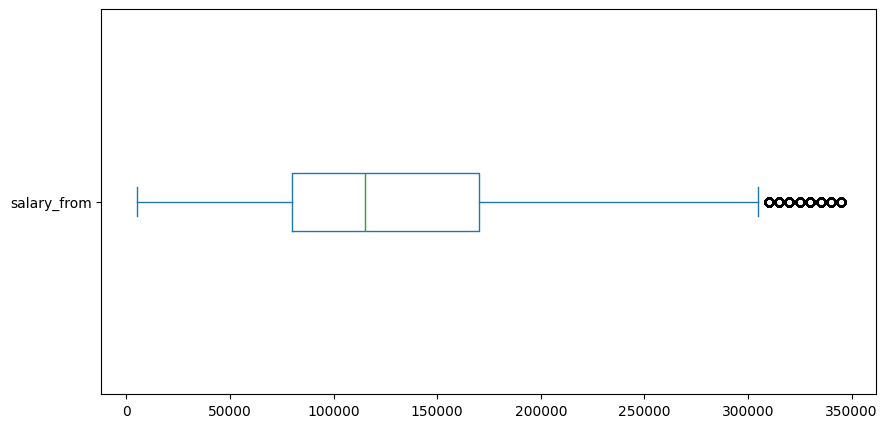

In [304]:
df_for_model['salary_from'].plot(kind='box', vert=False, figsize=(10, 5))

In [305]:
X, y = df_for_model.drop(columns=['vacancy_id', 'salary_from']), df_for_model[['salary_from']]

In [306]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [307]:
scaler = StandardScaler()
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [308]:
categorical_features = ['city', 'experience', 'employment_type']
numeric_features = ['salary_to']

encoded_train_features = encoder.fit_transform(X_train[categorical_features])
scaled_train_features = scaler.fit_transform(X_train[numeric_features])

encoded_test_features = encoder.transform(X_test[categorical_features])
scaled_test_features = scaler.transform(X_test[numeric_features])

feature_names = numeric_features + list(encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.DataFrame(
    np.hstack([scaled_train_features, encoded_train_features]),
    columns=feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    np.hstack([scaled_test_features, encoded_test_features]),
    columns=feature_names,
    index=X_test.index
)

In [309]:
best_mae = float('inf')
best_rmse = float('inf')
best_model = None

for k in range(1, 17):
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_encoded, y_train)

    prediction = knn.predict(X_test_encoded)

    current_mae = mae(y_test, prediction)
    current_rmse = mse(y_test, prediction) ** 0.5

    if current_mae < best_mae:
        best_mae = current_mae
        best_rmse = current_rmse
        best_model = knn

In [310]:
best_mae, best_rmse, best_model

(7457.020151483058, 10027.950636455107, KNeighborsRegressor(n_neighbors=14))

In [311]:
best_prediction = best_model.predict(X_test_encoded)

In [312]:
baseline_median_value = y_train.median()
baseline_mean_value = y_train.mean()

baseline_median_prediction = np.full(len(y_test), baseline_median_value)
baseline_mean_prediction = np.full(len(y_test), baseline_mean_value)

comparison = pd.DataFrame({
    'model': ['KNN', 'Baseline (median)', 'Baseline (mean)'],
    'MAE': [
        mae(y_test, best_prediction),
        mae(y_test, baseline_median_prediction),
        mae(y_test, baseline_mean_prediction)
    ],
    'RMSE': [
            mse(y_test, best_prediction) ** 0.5,
            mse(y_test, baseline_median_prediction) ** 0.5,
            mse(y_test, baseline_mean_prediction) ** 0.5
        ]
    })

comparison

,model,MAE,RMSE
0,KNN,7457.020151,10027.950636
1,Baseline (median),52283.245565,69964.949264
2,Baseline (mean),54447.398861,68041.008789


Попробуем заполнить пропуски в исходном датасете

In [313]:
missing_salary_from = df['salary_from'].isna() & df['salary_to'].notna()

X_missing = df.loc[missing_salary_from, categorical_features + numeric_features]
encoded_missing = encoder.transform(X_missing[categorical_features])
scaled_missing = scaler.transform(X_missing[numeric_features])

X_missing_encoded = pd.DataFrame(
    np.hstack([scaled_missing, encoded_missing]),
    columns=feature_names,
    index=X_missing.index
)

predicted_salary_from = best_model.predict(X_missing_encoded).ravel()
df.loc[missing_salary_from, 'salary_from'] = predicted_salary_from

df[['salary_from', 'salary_to']].isna().sum()

salary_from       0
salary_to      5191
dtype: int64

2. Повторим все то же самое для salary_to

In [314]:
Q1 = non_null_df['salary_to'].quantile(0.25)
Q3 = non_null_df['salary_to'].quantile(0.75)
IQR = Q3 - Q1

df_for_model = non_null_df[
    (non_null_df['salary_to'] >= Q1 - 1.5 * IQR) & (non_null_df['salary_to'] <= Q3 + 1.5 * IQR)
]

<Axes: >

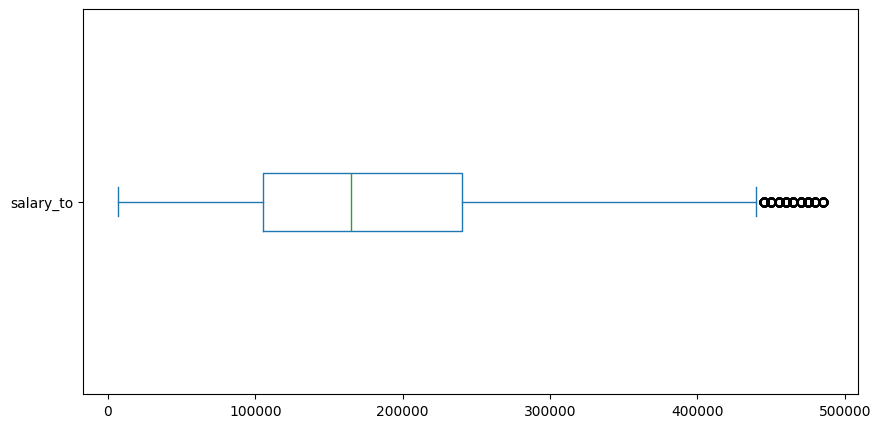

In [315]:
df_for_model['salary_to'].plot(kind='box', vert=False, figsize=(10, 5))

In [316]:
X, y = df_for_model.drop(columns=['vacancy_id', 'salary_to']), df_for_model[['salary_to']]

In [317]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [318]:
scaler = StandardScaler()
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [319]:
categorical_features = ['city', 'experience', 'employment_type']
numeric_features = ['salary_from']

encoded_train_features = encoder.fit_transform(X_train[categorical_features])
scaled_train_features = scaler.fit_transform(X_train[numeric_features])

encoded_test_features = encoder.transform(X_test[categorical_features])
scaled_test_features = scaler.transform(X_test[numeric_features])

feature_names = numeric_features + list(encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.DataFrame(
    np.hstack([scaled_train_features, encoded_train_features]),
    columns=feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    np.hstack([scaled_test_features, encoded_test_features]),
    columns=feature_names,
    index=X_test.index
)

In [320]:
best_mae = float('inf')
best_rmse = float('inf')
best_model = None

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_encoded, y_train)

    prediction = knn.predict(X_test_encoded)

    current_mae = mae(y_test, prediction)
    current_rmse = mse(y_test, prediction) ** 0.5

    if current_mae < best_mae:
        best_mae = current_mae
        best_rmse = current_rmse
        best_model = knn

In [321]:
best_mae, best_rmse, best_model

(10285.79779393077, 14012.624723759072, KNeighborsRegressor(n_neighbors=12))

In [322]:
best_prediction = best_model.predict(X_test_encoded)

In [323]:
baseline_median_value = y_train.median()
baseline_mean_value = y_train.mean()

baseline_median_prediction = np.full(len(y_test), baseline_median_value)
baseline_mean_prediction = np.full(len(y_test), baseline_mean_value)

comparison = pd.DataFrame({
    'model': ['KNN', 'Baseline (median)', 'Baseline (mean)'],
    'MAE': [
        mae(y_test, best_prediction),
        mae(y_test, baseline_median_prediction),
        mae(y_test, baseline_mean_prediction)
    ],
    'RMSE': [
            mse(y_test, best_prediction) ** 0.5,
            mse(y_test, baseline_median_prediction) ** 0.5,
            mse(y_test, baseline_mean_prediction) ** 0.5
        ]
    })

comparison

,model,MAE,RMSE
0,KNN,10285.797794,14012.624724
1,Baseline (median),78233.619682,101117.900830
2,Baseline (mean),79986.697948,99502.509458


In [324]:
missing_salary_to = df['salary_to'].isna()

X_missing = df.loc[missing_salary_to, categorical_features + numeric_features]
encoded_missing = encoder.transform(X_missing[categorical_features])
scaled_missing = scaler.transform(X_missing[numeric_features])

X_missing_encoded = pd.DataFrame(
    np.hstack([scaled_missing, encoded_missing]),
    columns=feature_names,
    index=X_missing.index
)

predicted_salary_to = best_model.predict(X_missing_encoded).ravel()
df.loc[missing_salary_to, 'salary_to'] = predicted_salary_to

df[['salary_from', 'salary_to']].isna().sum()

salary_from    0
salary_to      0
dtype: int64

In [325]:
df.head()

,vacancy_id,salary_from,salary_to,experience,city,employment_type
0,37351176,60000.0,70000.000000,Нет опыта,Екатеринбург,Удалённая работа
1,53503796,140000.0,210000.000000,От 1 года до 3 лет,Москва,Полная занятость
3,40619665,145000.0,215000.000000,От 1 года до 3 лет,Нижний Новгород,Полная занятость
5,21241867,60000.0,70000.000000,Нет опыта,Москва,Стажировка
6,45942522,245000.0,363333.333333,От 1 года до 3 лет,Москва,Удалённая работа


In [326]:
df.to_csv('vacancies_filled.csv', index=False)